# CUDA Retraining Notebook

Use this notebook to retrain the project U-Net on your BUSI images with NVIDIA CUDA enabled.

- Dataset folder: `D:\u-net-biomedical-flow-project\data\images`
- Output checkpoints: `experiments/notebook_run/models/unet_model.pth` and `experiments/notebook_run/checkpoint/best_unet_model.pt`
- Training mode: synthetic noisy input -> clean target, so the model learns denoising from your image set


In [6]:
from pathlib import Path
import random
import sys
import time

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image

PROJECT_ROOT = Path(r"D:\u-net-biomedical-flow-project")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from backend.inference import UNet
from backend.loss_functions import build_loss


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("CUDA version:", torch.version.cuda)
    print("cuDNN version:", torch.backends.cudnn.version())
    x = torch.randn(2, 2, device=device)
    y = x @ x
    print("GPU tensor test:", y)
else:
    print("Running on CPU fallback")


Device: cuda
CUDA available: True
GPU name: NVIDIA GeForce RTX 4050 Laptop GPU
CUDA version: 12.8
cuDNN version: 91900
GPU tensor test: tensor([[1.0480, 0.1328],
        [0.1187, 1.2866]], device='cuda:0')


In [8]:
# Reproducibility and training config
seed = 42
batch_size = 8
lr = 1e-3
epochs = 20
image_size = 256
loss_mode = "mse"  # try: mse, l1, frequency
val_split = 0.2
noise_std = 0.02
data_dir = Path(r"D:\u-net-biomedical-flow-project\data\images")
output_dir = Path(r"D:\u-net-biomedical-flow-project\experiments\notebook_run")

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.benchmark = True

def resize_and_normalize(image_path: Path) -> torch.Tensor:
    image = Image.open(image_path).convert("L").resize((image_size, image_size))
    array = np.asarray(image, dtype=np.float32) / 255.0
    array = np.clip(array, 0.0, 1.0)
    return torch.from_numpy(array).unsqueeze(0)

print("Data dir exists:", data_dir.exists())
print("Output dir:", output_dir)


Data dir exists: True
Output dir: D:\u-net-biomedical-flow-project\experiments\notebook_run


In [9]:
from torch.utils.data import Dataset, DataLoader, random_split

class UltrasoundPairDataset(Dataset):
    def __init__(self, root_dir: Path, noise_std: float = 0.02):
        self.root_dir = root_dir
        self.noise_std = noise_std
        self.files = [p for p in sorted(root_dir.iterdir()) if p.suffix.lower() in {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}]

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        clean = resize_and_normalize(self.files[idx])
        noisy = torch.clamp(clean + torch.randn_like(clean) * self.noise_std, 0.0, 1.0)
        return noisy, clean

if not data_dir.exists():
    raise FileNotFoundError(f"Dataset folder not found: {data_dir}")

dataset = UltrasoundPairDataset(data_dir, noise_std=noise_std)
val_size = max(1, int(len(dataset) * val_split))
train_size = len(dataset) - val_size
if train_size < 1:
    raise ValueError("Not enough images to create a train split")

generator = torch.Generator().manual_seed(seed)
train_ds, val_ds = random_split(dataset, [train_size, val_size], generator=generator)
print("Train samples:", len(train_ds))
print("Val samples:", len(val_ds))


Train samples: 1263
Val samples: 315


In [10]:
from torch.utils.data import DataLoader
import os
import time

# In Windows + notebook kernels, worker processes can hang; prefer safe defaults.
if os.name == "nt":
    worker_candidates = [0, 2] if torch.cuda.is_available() else [0]
else:
    worker_candidates = [2, 0] if torch.cuda.is_available() else [0]

train_loader = None
val_loader = None
sample_noisy = None
sample_clean = None
selected_workers = 0

for candidate_workers in worker_candidates:
    start = time.time()
    try:
        loader_kwargs = {
            "batch_size": batch_size,
            "num_workers": candidate_workers,
            "pin_memory": torch.cuda.is_available(),
        }
        if candidate_workers > 0:
            loader_kwargs["persistent_workers"] = True

        print(f"Trying DataLoader with num_workers={candidate_workers}...", flush=True)
        train_loader = DataLoader(train_ds, shuffle=True, **loader_kwargs)
        val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)

        sample_noisy, sample_clean = next(iter(train_loader))
        selected_workers = candidate_workers
        elapsed = time.time() - start
        print(f"DataLoader ready with num_workers={selected_workers} in {elapsed:.2f}s", flush=True)
        break
    except Exception as exc:
        elapsed = time.time() - start
        print(
            f"num_workers={candidate_workers} failed after {elapsed:.2f}s: {type(exc).__name__}: {exc}",
            flush=True,
        )
        train_loader = None
        val_loader = None

if train_loader is None or val_loader is None:
    raise RuntimeError("Failed to initialize DataLoaders with all tested worker settings")

print("Batch noisy shape:", tuple(sample_noisy.shape))
print("Batch clean shape:", tuple(sample_clean.shape))

Trying DataLoader with num_workers=0...
DataLoader ready with num_workers=0 in 0.05s
Batch noisy shape: (8, 1, 256, 256)
Batch clean shape: (8, 1, 256, 256)


## Load U-Net and Training Components

This section initializes the U-Net, optionally resumes from the last checkpoint, and prepares the optimizer and scheduler for CUDA mixed-precision training.


In [11]:
model = UNet().to(device)
resume_path = output_dir / "checkpoint" / "best_unet_model.pt"
resume_epoch = 0
best_val_loss = float("inf")

if resume_path.exists():
    state_dict = torch.load(resume_path, map_location=device)
    model.load_state_dict(state_dict, strict=False)
    print(f"Resumed weights from {resume_path}")
else:
    print("Starting from fresh U-Net weights")

criterion = build_loss(loss_mode)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
scaler = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
use_amp = device.type == "cuda"

print("Loss mode:", loss_mode)
print("AMP enabled:", use_amp)


Resumed weights from D:\u-net-biomedical-flow-project\experiments\notebook_run\checkpoint\best_unet_model.pt
Loss mode: mse
AMP enabled: True


## Mixed-Precision Training Loop

Run this cell to train the model on your CUDA GPU. It prints epoch metrics and saves the best checkpoint automatically.


In [12]:
history = {"train_loss": [], "val_loss": [], "lr": []}

best_model_dir = output_dir / "models"
best_ckpt_dir = output_dir / "checkpoint"
best_model_dir.mkdir(parents=True, exist_ok=True)
best_ckpt_dir.mkdir(parents=True, exist_ok=True)
best_model_path = best_model_dir / "unet_model.pth"
best_ckpt_path = best_ckpt_dir / "best_unet_model.pt"

print(f"Starting training on {device} | epochs={epochs}, batch_size={batch_size}", flush=True)
print(f"Train batches/epoch: {len(train_loader)} | Val batches/epoch: {len(val_loader)}", flush=True)

total_training_start = time.time()
epoch_durations = []

for epoch in range(resume_epoch, epochs):
    epoch_start = time.time()
    model.train()
    running_train_loss = 0.0

    train_log_every = max(1, len(train_loader) // 5)
    print(f"\n[Epoch {epoch + 1}/{epochs}] Training started...", flush=True)

    for batch_idx, (noisy, clean) in enumerate(train_loader, start=1):
        noisy = noisy.to(device, non_blocking=True)
        clean = clean.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        if use_amp:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                pred = model(noisy)
                loss = criterion(pred, clean)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            pred = model(noisy)
            loss = criterion(pred, clean)
            loss.backward()
            optimizer.step()

        running_train_loss += float(loss.item())

        if batch_idx % train_log_every == 0 or batch_idx == len(train_loader):
            pct = 100.0 * batch_idx / max(1, len(train_loader))
            avg_so_far = running_train_loss / batch_idx
            print(
                f"  Train progress: {batch_idx}/{len(train_loader)} ({pct:.0f}%) | "
                f"Avg loss so far: {avg_so_far:.6f}",
                flush=True,
            )

    train_loss = running_train_loss / max(1, len(train_loader))

    model.eval()
    running_val_loss = 0.0
    val_log_every = max(1, len(val_loader) // 2)
    print(f"[Epoch {epoch + 1}/{epochs}] Validation started...", flush=True)

    with torch.no_grad():
        for val_idx, (noisy, clean) in enumerate(val_loader, start=1):
            noisy = noisy.to(device, non_blocking=True)
            clean = clean.to(device, non_blocking=True)
            if use_amp:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    pred = model(noisy)
                    loss = criterion(pred, clean)
            else:
                pred = model(noisy)
                loss = criterion(pred, clean)
            running_val_loss += float(loss.item())

            if val_idx % val_log_every == 0 or val_idx == len(val_loader):
                print(f"  Val progress: {val_idx}/{len(val_loader)}", flush=True)

    val_loss = running_val_loss / max(1, len(val_loader))
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(optimizer.param_groups[0]["lr"] )

    elapsed = time.time() - epoch_start
    epoch_durations.append(elapsed)
    avg_epoch_time = sum(epoch_durations) / len(epoch_durations)
    remaining_epochs = max(0, epochs - (epoch + 1))
    eta_seconds = avg_epoch_time * remaining_epochs

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.6f} | "
        f"Val Loss: {val_loss:.6f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.2e} | "
        f"Time: {elapsed:.1f}s | "
        f"ETA: {eta_seconds/60:.1f} min",
        flush=True,
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "scaler_state_dict": scaler.state_dict() if use_amp else None,
                "best_val_loss": best_val_loss,
                "history": history,
                "loss_mode": loss_mode,
                "batch_size": batch_size,
                "lr": lr,
                "noise_std": noise_std,
            },
            best_ckpt_path,
        )
        print(f"Saved best checkpoint to {best_model_path} and {best_ckpt_path}", flush=True)

total_elapsed = time.time() - total_training_start
print(f"\nTraining complete in {total_elapsed/60:.1f} min. Best validation loss: {best_val_loss:.6f}", flush=True)

Starting training on cuda | epochs=20, batch_size=8
Train batches/epoch: 158 | Val batches/epoch: 40

[Epoch 1/20] Training started...
  Train progress: 31/158 (20%) | Avg loss so far: 0.050614
  Train progress: 62/158 (39%) | Avg loss so far: 0.027656
  Train progress: 93/158 (59%) | Avg loss so far: 0.019302
  Train progress: 124/158 (78%) | Avg loss so far: 0.015183
  Train progress: 155/158 (98%) | Avg loss so far: 0.012459
  Train progress: 158/158 (100%) | Avg loss so far: 0.012259
[Epoch 1/20] Validation started...
  Val progress: 20/40
  Val progress: 40/40
Epoch 1/20 | Train Loss: 0.012259 | Val Loss: 0.000792 | LR: 9.94e-04 | Time: 53.9s | ETA: 17.1 min
Saved best checkpoint to D:\u-net-biomedical-flow-project\experiments\notebook_run\models\unet_model.pth and D:\u-net-biomedical-flow-project\experiments\notebook_run\checkpoint\best_unet_model.pt

[Epoch 2/20] Training started...
  Train progress: 31/158 (20%) | Avg loss so far: 0.001194
  Train progress: 62/158 (39%) | Avg l

## Resume, Test, and Export

This last section shows how to resume from the checkpoint and run a quick GPU inference sanity check.


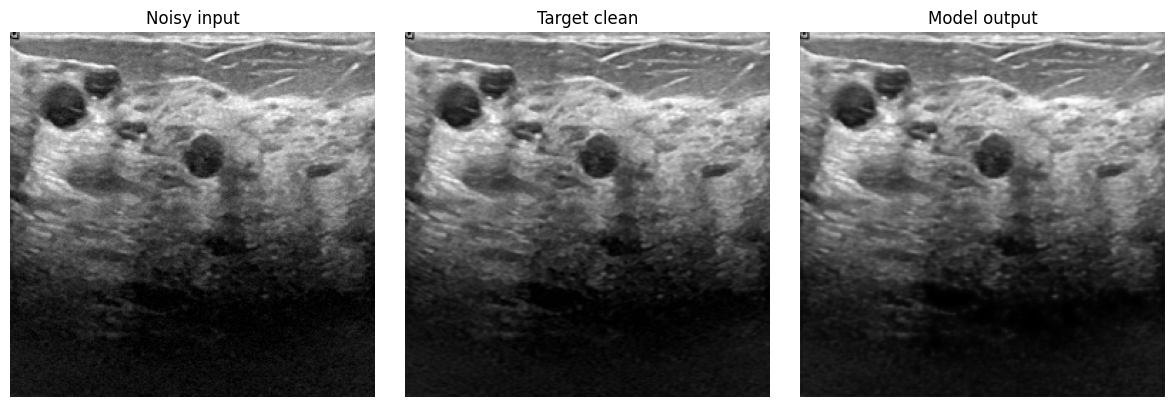

Final model weights: D:\u-net-biomedical-flow-project\experiments\notebook_run\models\unet_model.pth
Best training checkpoint: D:\u-net-biomedical-flow-project\experiments\notebook_run\checkpoint\best_unet_model.pt


In [13]:
from pathlib import Path

def load_checkpoint(path: Path):
    if not path.exists():
        print(f"No checkpoint found at {path}")
        return 0
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model_state_dict"], strict=False)
    optimizer.load_state_dict(ckpt["optimizer_state_dict"])
    scheduler.load_state_dict(ckpt["scheduler_state_dict"])
    if use_amp and ckpt.get("scaler_state_dict") is not None:
        scaler.load_state_dict(ckpt["scaler_state_dict"])
    print(f"Resumed training state from {path}")
    return ckpt.get("epoch", 0)

# Example: uncomment to resume
# resume_epoch = load_checkpoint(best_ckpt_path)

if 'val_loader' not in globals():
    print("Skipping sample visualization: run the dataset/DataLoader cells first.")
else:
    sample_noisy, sample_clean = next(iter(val_loader))
    model.eval()
    with torch.no_grad():
        sample_noisy = sample_noisy.to(device)
        if use_amp:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                sample_pred = model(sample_noisy)
        else:
            sample_pred = model(sample_noisy)

    noisy_img = sample_noisy[0, 0].detach().cpu().numpy()
    clean_img = sample_clean[0, 0].detach().cpu().numpy()
    pred_img = sample_pred[0, 0].detach().cpu().numpy()

    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(noisy_img, cmap="gray")
    axes[0].set_title("Noisy input")
    axes[1].imshow(clean_img, cmap="gray")
    axes[1].set_title("Target clean")
    axes[2].imshow(pred_img, cmap="gray")
    axes[2].set_title("Model output")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

best_model_path = globals().get('best_model_path', Path(r"D:\u-net-biomedical-flow-project\experiments\notebook_run\models\unet_model.pth"))
best_ckpt_path = globals().get('best_ckpt_path', Path(r"D:\u-net-biomedical-flow-project\experiments\notebook_run\checkpoint\best_unet_model.pt"))
print("Final model weights:", best_model_path)
print("Best training checkpoint:", best_ckpt_path)


In [16]:
import csv
import json
from datetime import datetime, timezone

export_dir = output_dir / 'exports'
export_dir.mkdir(parents=True, exist_ok=True)

timestamp = datetime.now(timezone.utc).strftime('%Y%m%dT%H%M%SZ')
history_export_path = export_dir / f'training_history_{timestamp}.json'
history_csv_path = export_dir / f'training_history_{timestamp}.csv'
summary_path = export_dir / f'run_summary_{timestamp}.json'
preview_path = export_dir / f'preview_{timestamp}.png'

history_payload = {
    'train_loss': history.get('train_loss', []),
    'val_loss': history.get('val_loss', []),
    'lr': history.get('lr', []),
}
with history_export_path.open('w', encoding='utf-8') as handle:
    json.dump(history_payload, handle, indent=2)

rows = zip(history_payload['train_loss'], history_payload['val_loss'], history_payload['lr'])
with history_csv_path.open('w', encoding='utf-8', newline='') as handle:
    writer = csv.writer(handle)
    writer.writerow(['epoch', 'train_loss', 'val_loss', 'lr'])
    for index, (train_value, val_value, lr_value) in enumerate(rows, start=1):
        writer.writerow([index, train_value, val_value, lr_value])

summary_payload = {
    'timestamp_utc': timestamp,
    'device': str(device),
    'torch_version': torch.__version__,
    'torch_cuda_version': torch.version.cuda,
    'cuda_available': torch.cuda.is_available(),
    'epochs': epochs,
    'batch_size': batch_size,
    'image_size': image_size,
    'loss_mode': loss_mode,
    'best_val_loss': best_val_loss,
    'selected_workers': globals().get('selected_workers', None),
    'best_model_path': str(best_model_path),
    'best_ckpt_path': str(best_ckpt_path),
    'history_json_path': str(history_export_path),
    'history_csv_path': str(history_csv_path),
    'total_elapsed_seconds': total_elapsed if 'total_elapsed' in globals() else None,
    'train_loss_last': history_payload['train_loss'][-1] if history_payload['train_loss'] else None,
    'val_loss_last': history_payload['val_loss'][-1] if history_payload['val_loss'] else None,
}
with summary_path.open('w', encoding='utf-8') as handle:
    json.dump(summary_payload, handle, indent=2)

if 'sample_noisy' in globals() and 'sample_clean' in globals() and 'sample_pred' in globals():
    import matplotlib.pyplot as plt
    noisy_preview = sample_noisy[0, 0].detach().cpu().numpy()
    clean_preview = sample_clean[0, 0].detach().cpu().numpy()
    pred_preview = sample_pred[0, 0].detach().cpu().numpy()
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(noisy_preview, cmap='gray')
    axes[0].set_title('Noisy input')
    axes[1].imshow(clean_preview, cmap='gray')
    axes[1].set_title('Target clean')
    axes[2].imshow(pred_preview, cmap='gray')
    axes[2].set_title('Model output')
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(preview_path, dpi=150, bbox_inches='tight')
    plt.close(fig)
    preview_message = str(preview_path)
else:
    preview_message = 'not created (sample tensors unavailable)'

print('Exported training history JSON:', history_export_path)
print('Exported training history CSV:', history_csv_path)
print('Exported run summary JSON:', summary_path)
print('Exported preview image:', preview_message)

Exported training history JSON: D:\u-net-biomedical-flow-project\experiments\notebook_run\exports\training_history_20260423T133948Z.json
Exported training history CSV: D:\u-net-biomedical-flow-project\experiments\notebook_run\exports\training_history_20260423T133948Z.csv
Exported run summary JSON: D:\u-net-biomedical-flow-project\experiments\notebook_run\exports\run_summary_20260423T133948Z.json
Exported preview image: D:\u-net-biomedical-flow-project\experiments\notebook_run\exports\preview_20260423T133948Z.png


In [18]:
# Quick experiment sweep: compare epochs, image_size, and loss_mode
import csv
import json
from datetime import datetime, timezone

from torch.utils.data import DataLoader, random_split

experiment_grid = [
    {"name": "mse_e6_s256", "epochs": 6, "image_size": 256, "loss_mode": "mse"},
    {"name": "l1_e6_s256", "epochs": 6, "image_size": 256, "loss_mode": "l1"},
    {"name": "mse_e6_s192", "epochs": 6, "image_size": 192, "loss_mode": "mse"},
]

sweep_output_dir = output_dir / "exports"
sweep_output_dir.mkdir(parents=True, exist_ok=True)
sweep_timestamp = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")

def run_single_experiment(cfg: dict) -> dict:
    global image_size
    image_size = int(cfg["image_size"])
    local_seed = seed
    random.seed(local_seed)
    np.random.seed(local_seed)
    torch.manual_seed(local_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(local_seed)

    # Rebuild dataset/loaders so image_size is applied during image loading.
    dataset_local = UltrasoundPairDataset(data_dir, noise_std=noise_std)
    val_size_local = max(1, int(len(dataset_local) * val_split))
    train_size_local = len(dataset_local) - val_size_local
    generator_local = torch.Generator().manual_seed(local_seed)
    train_ds_local, val_ds_local = random_split(dataset_local, [train_size_local, val_size_local], generator=generator_local)

    loader_kwargs_local = {
        "batch_size": batch_size,
        "num_workers": 0,
        "pin_memory": torch.cuda.is_available(),
    }
    train_loader_local = DataLoader(train_ds_local, shuffle=True, **loader_kwargs_local)
    val_loader_local = DataLoader(val_ds_local, shuffle=False, **loader_kwargs_local)

    model_local = UNet().to(device)
    criterion_local = build_loss(cfg["loss_mode"])
    optimizer_local = torch.optim.AdamW(model_local.parameters(), lr=lr, weight_decay=1e-4)
    scheduler_local = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_local, T_max=cfg["epochs"], eta_min=1e-6)
    scaler_local = torch.amp.GradScaler("cuda", enabled=device.type == "cuda")
    use_amp_local = device.type == "cuda"

    best_val_local = float("inf")
    train_last = None
    val_last = None
    run_start = time.time()

    for _ in range(cfg["epochs"]):
        model_local.train()
        running_train = 0.0
        for noisy_b, clean_b in train_loader_local:
            noisy_b = noisy_b.to(device, non_blocking=True)
            clean_b = clean_b.to(device, non_blocking=True)
            optimizer_local.zero_grad(set_to_none=True)
            if use_amp_local:
                with torch.autocast(device_type="cuda", dtype=torch.float16):
                    pred_b = model_local(noisy_b)
                    loss_b = criterion_local(pred_b, clean_b)
                scaler_local.scale(loss_b).backward()
                scaler_local.step(optimizer_local)
                scaler_local.update()
            else:
                pred_b = model_local(noisy_b)
                loss_b = criterion_local(pred_b, clean_b)
                loss_b.backward()
                optimizer_local.step()
            running_train += float(loss_b.item())
        train_last = running_train / max(1, len(train_loader_local))

        model_local.eval()
        running_val = 0.0
        with torch.no_grad():
            for noisy_b, clean_b in val_loader_local:
                noisy_b = noisy_b.to(device, non_blocking=True)
                clean_b = clean_b.to(device, non_blocking=True)
                if use_amp_local:
                    with torch.autocast(device_type="cuda", dtype=torch.float16):
                        pred_b = model_local(noisy_b)
                        loss_b = criterion_local(pred_b, clean_b)
                else:
                    pred_b = model_local(noisy_b)
                    loss_b = criterion_local(pred_b, clean_b)
                running_val += float(loss_b.item())
        val_last = running_val / max(1, len(val_loader_local))
        best_val_local = min(best_val_local, val_last)
        scheduler_local.step()

    elapsed = time.time() - run_start
    return {
        "name": cfg["name"],
        "epochs": cfg["epochs"],
        "image_size": cfg["image_size"],
        "loss_mode": cfg["loss_mode"],
        "train_loss_last": train_last,
        "val_loss_last": val_last,
        "best_val_loss": best_val_local,
        "elapsed_seconds": elapsed,
    }

results = []
for cfg in experiment_grid:
    print(f"Running {cfg['name']} ...", flush=True)
    result = run_single_experiment(cfg)
    results.append(result)
    print(
        f"  done | best_val_loss={result['best_val_loss']:.6f} | "
        f"last_val={result['val_loss_last']:.6f} | time={result['elapsed_seconds']:.1f}s",
        flush=True,
    )

results_sorted = sorted(results, key=lambda r: r["best_val_loss"] )

sweep_json = sweep_output_dir / f"experiment_sweep_{sweep_timestamp}.json"
sweep_csv = sweep_output_dir / f"experiment_sweep_{sweep_timestamp}.csv"

with sweep_json.open("w", encoding="utf-8") as f:
    json.dump(results_sorted, f, indent=2)

with sweep_csv.open("w", encoding="utf-8", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=[
        "name", "epochs", "image_size", "loss_mode", "train_loss_last", "val_loss_last", "best_val_loss", "elapsed_seconds"
    ])
    writer.writeheader()
    writer.writerows(results_sorted)

print("\nExperiment ranking (best_val_loss):")
for i, row in enumerate(results_sorted, start=1):
    print(
        f"{i}. {row['name']} | best_val={row['best_val_loss']:.6f} | "
        f"last_val={row['val_loss_last']:.6f} | time={row['elapsed_seconds']:.1f}s"
    )

print("Exported sweep JSON:", sweep_json)
print("Exported sweep CSV:", sweep_csv)

Running mse_e6_s256 ...
  done | best_val_loss=0.000206 | last_val=0.000206 | time=105.2s
Running l1_e6_s256 ...
  done | best_val_loss=0.190615 | last_val=0.190615 | time=108.9s
Running mse_e6_s192 ...
  done | best_val_loss=0.000292 | last_val=0.000292 | time=77.5s

Experiment ranking (best_val_loss):
1. mse_e6_s256 | best_val=0.000206 | last_val=0.000206 | time=105.2s
2. mse_e6_s192 | best_val=0.000292 | last_val=0.000292 | time=77.5s
3. l1_e6_s256 | best_val=0.190615 | last_val=0.190615 | time=108.9s
Exported sweep JSON: D:\u-net-biomedical-flow-project\experiments\notebook_run\exports\experiment_sweep_20260423T142158Z.json
Exported sweep CSV: D:\u-net-biomedical-flow-project\experiments\notebook_run\exports\experiment_sweep_20260423T142158Z.csv


## Run It

Use this command from the project root if you want to execute the same notebook logic in script form:

```powershell
python -m backend.retrain_unet --data-dir D:\u-net-biomedical-flow-project\data\images --epochs 20 --loss-mode mse --noise-std 0.02
```
